In [20]:
import pandas as pd

# Carregando a base tratada da Atividade 8
df = pd.read_csv("dados_tratados.csv")

# Conferindo as dimensões da base
print("Dimensões da base:", df.shape)

# Visualizando as primeiras linhas
display(df.head())

Dimensões da base: (392692, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [21]:
# Convertendo a coluna InvoiceDate para o formato de data
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Ordenando os registros pela data da compra
df = df.sort_values("InvoiceDate")

# Definindo o ponto de corte em 80% do período
data_corte = df["InvoiceDate"].quantile(0.80)

print("Data de corte:", data_corte)

Data de corte: 2011-11-01 15:55:00


In [22]:
# Separando os dados anteriores e posteriores à data de corte
dados_passado = df[df["InvoiceDate"] <= data_corte].copy()
dados_futuro = df[df["InvoiceDate"] > data_corte].copy()

print("Registros no período passado:", len(dados_passado))
print("Registros no período futuro:", len(dados_futuro))

Registros no período passado: 314183
Registros no período futuro: 78509


In [23]:
# Criando um conjunto com os clientes que realizaram compras no período futuro
clientes_futuros = set(dados_futuro["CustomerID"].unique())

print("Quantidade de clientes que compraram no futuro:", len(clientes_futuros))

Quantidade de clientes que compraram no futuro: 1883


In [24]:
# Criando as características dos clientes usando somente os dados do passado
X = dados_passado.groupby("CustomerID").agg(
    QuantidadeTotal=("Quantity", "sum"),
    PrecoMedio=("UnitPrice", "mean"),
    QuantidadePedidos=("InvoiceNo", "nunique"),
    UltimaCompra=("InvoiceDate", "max"),
    Pais=("Country", "first")
).reset_index()

# Calculando a recência:
# quantidade de dias desde a última compra do cliente até a data de corte
X["Recencia"] = (data_corte - X["UltimaCompra"]).dt.days

# A data da última compra não será usada diretamente no modelo,
# pois já foi utilizada para calcular a recência
X = X.drop(columns=["UltimaCompra"])

# Agrupando os países em duas categorias
# Reino Unido permanece separado e os demais países são agrupados como "Outros"
X["Pais"] = X["Pais"].apply(
    lambda pais: "Reino Unido" if pais == "United Kingdom" else "Outros"
)

# Removendo o identificador do cliente das características
X = X.drop(columns=["CustomerID"])

# Criando o alvo:
# 1 = cliente realizou uma nova compra no período futuro
# 0 = cliente não realizou uma nova compra no período futuro
y = dados_passado.groupby("CustomerID").apply(
    lambda grupo: 1 if grupo["CustomerID"].iloc[0] in clientes_futuros else 0
)

print("Dimensões do X:", X.shape)
print("Dimensões do y:", y.shape)

print("\nColunas do X:")
print(X.columns.tolist())

print("\nPaíses após agrupamento:")
print(X["Pais"].value_counts())

print("\nPrimeiras linhas do X:")
display(X.head())

print("\nPrimeiros valores do y:")
display(y.head())

Dimensões do X: (3985, 5)
Dimensões do y: (3985,)

Colunas do X:
['QuantidadeTotal', 'PrecoMedio', 'QuantidadePedidos', 'Pais', 'Recencia']

Países após agrupamento:
Pais
Reino Unido    3599
Outros          386
Name: count, dtype: int64

Primeiras linhas do X:


/tmp/ipykernel_955/489549277.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  y = dados_passado.groupby("CustomerID").apply(


,QuantidadeTotal,PrecoMedio,QuantidadePedidos,Pais,Recencia
0,74215,1.040000,1,Reino Unido,287
1,2266,2.734912,6,Outros,1
2,2341,5.764839,4,Outros,37
3,197,3.841176,1,Outros,271
4,409,18.108286,7,Outros,34



Primeiros valores do y:


,0
CustomerID,
12346.0,0
12347.0,1
12348.0,0
12350.0,0
12352.0,1


## Expectativa inicial

Antes do treinamento, espero que o modelo consiga identificar alguns padrões de comportamento dos clientes que indiquem maior probabilidade de uma nova compra. Como o conjunto possui clientes que compraram novamente e clientes que não compraram novamente, espero obter um resultado melhor que o baseline, mas sem esperar uma precisão muito alta, já que estamos utilizando um primeiro modelo simples.

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
# Separando os dados em treino e teste antes da transformação das categorias
# 80% dos dados serão usados para treino e 20% para teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Transformando "Pais" em variáveis numéricas separadamente
# A transformação é baseada somente nos dados de treino
X_train = pd.get_dummies(X_train, columns=["Pais"], dtype=int)
X_test = pd.get_dummies(X_test, columns=["Pais"], dtype=int)

# Garantindo que treino e teste tenham exatamente as mesmas colunas
X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

print("Dimensões do X_train:", X_train.shape)
print("Dimensões do X_test:", X_test.shape)
print("Dimensões do y_train:", y_train.shape)
print("Dimensões do y_test:", y_test.shape)

Dimensões do X_train: (3188, 6)
Dimensões do X_test: (797, 6)
Dimensões do y_train: (3188,)
Dimensões do y_test: (797,)


In [27]:
print("Proporção das classes no conjunto de treino:")
print(y_train.value_counts(normalize=True))

print("\nProporção das classes no conjunto de teste:")
print(y_test.value_counts(normalize=True))

Proporção das classes no conjunto de treino:
0    0.61606
1    0.38394
Name: proportion, dtype: float64

Proporção das classes no conjunto de teste:
0    0.61606
1    0.38394
Name: proportion, dtype: float64


In [28]:
from sklearn.metrics import accuracy_score

# Baseline: sempre prevê a classe mais frequente no conjunto de treino
classe_majoritaria = y_train.mode()[0]

# Criando as previsões do baseline
y_pred_baseline = [classe_majoritaria] * len(y_test)

# Calculando a acurácia do baseline
acuracia_baseline = accuracy_score(y_test, y_pred_baseline)

print("Classe majoritária:", classe_majoritaria)
print("Acurácia do baseline:", acuracia_baseline)

Classe majoritária: 0
Acurácia do baseline: 0.616060225846926


## Escolha do primeiro modelo

Foi escolhida a Árvore de Decisão como primeiro modelo de Machine Learning. O problema foi estruturado como uma classificação binária, em que o objetivo é prever se o cliente realizará uma nova compra. A escolha também considera que o conjunto possui poucas características e que a árvore permite interpretar de forma simples quais condições influenciam as previsões

## Critério de divisão dos dados

A separação temporal já foi realizada na construção do problema: as características dos clientes foram calculadas somente com compras anteriores à data de corte, enquanto o alvo foi definido a partir das compras posteriores.

Depois dessa etapa, cada linha representa um cliente com características calculadas no passado e um resultado futuro já definido. Por isso, foi utilizada uma divisão aleatória de 80% para treino e 20% para teste, com `stratify=y` para manter a proporção das classes nos dois conjuntos.

In [29]:
from sklearn.tree import DecisionTreeClassifier

In [30]:
# Treinando a primeira Árvore de Decisão
# A profundidade máxima de 5 mantém o modelo relativamente simples
# e facilita a interpretação das decisões tomadas pela árvore
modelo = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

modelo.fit(X_train, y_train)

print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


In [31]:
# Realizando as previsões com os dados de teste
y_pred = modelo.predict(X_test)

print("Quantidade de previsões realizadas:", len(y_pred))
print("\nPrimeiras 10 previsões:")
print(y_pred[:10])

Quantidade de previsões realizadas: 797

Primeiras 10 previsões:
[1 0 0 0 0 0 0 1 1 0]


In [32]:
# Comparando os valores reais com as previsões do modelo
comparacao = pd.DataFrame({
    "Real": y_test.values,
    "Previsto": y_pred
})

print("Amostra de valores reais x previstos:")
display(comparacao.head(10))

Amostra de valores reais x previstos:


,Real,Previsto
0,1,1
1,0,0
2,0,0
3,1,0
4,0,0
5,1,0
6,1,0
7,1,1
8,1,1
9,0,0


In [33]:
from sklearn.metrics import accuracy_score

# Calculando a acurácia da Árvore de Decisão
acuracia_modelo = accuracy_score(y_test, y_pred)

print("Acurácia do modelo:", acuracia_modelo)
print("Acurácia do baseline:", acuracia_baseline)

Acurácia do modelo: 0.7239648682559598
Acurácia do baseline: 0.616060225846926


In [34]:
# Treinando uma segunda Árvore de Decisão com profundidade diferente
modelo_2 = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

modelo_2.fit(X_train, y_train)

# Realizando as previsões da segunda árvore
y_pred_2 = modelo_2.predict(X_test)

# Calculando a acurácia da segunda árvore
acuracia_modelo_2 = accuracy_score(y_test, y_pred_2)

print("Acurácia da Árvore 1 (profundidade 5):", acuracia_modelo)
print("Acurácia da Árvore 2 (profundidade 3):", acuracia_modelo_2)

Acurácia da Árvore 1 (profundidade 5): 0.7239648682559598
Acurácia da Árvore 2 (profundidade 3): 0.7227101631116688


In [35]:
# Comparação entre o baseline e as duas Árvores de Decisão
comparacao_modelos = pd.DataFrame({
    "Modelo": [
        "Baseline",
        "Árvore de Decisão - profundidade 5",
        "Árvore de Decisão - profundidade 3"
    ],
    "Acurácia": [
        acuracia_baseline,
        acuracia_modelo,
        acuracia_modelo_2
    ]
})

display(comparacao_modelos)

,Modelo,Acurácia
0,Baseline,0.616060
1,Árvore de Decisão - profundidade 5,0.723965
2,Árvore de Decisão - profundidade 3,0.722710


In [36]:
from sklearn.metrics import precision_score, recall_score

# Calculando precisão e recall da Árvore de Decisão principal
precisao = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Precisão do modelo:", precisao)
print("Recall do modelo:", recall)

Precisão do modelo: 0.7866666666666666
Recall do modelo: 0.38562091503267976


## Leitura crítica dos resultados

Os resultados mostram que a Árvore de Decisão apresentou acurácia de 72,40%, acima do baseline de 61,61%. A segunda árvore, com profundidade 3, apresentou acurácia de 72,27%, resultado muito próximo da primeira árvore, com profundidade 5.

Apesar da acurácia de 72,40%, a análise das outras métricas mostra uma diferença entre precisão e recall. A precisão foi de 78,67%, enquanto o recall foi de 38,56%. Isso indica que o modelo apresenta maior capacidade de acertar quando prevê que um cliente fará uma nova compra, mas identifica apenas uma parte dos clientes que realmente voltaram a comprar.

Os resultados fazem sentido para o problema analisado e não indicam, neste momento, um resultado perfeito. A diferença entre as métricas mostra que ainda há espaço para investigar o comportamento do modelo e testar outras formas de avaliação nas próximas etapas.

## Dificuldades e como foram tratadas

Durante a construção do modelo, foi necessário ajustar a preparação dos dados para evitar possíveis problemas no treinamento. Foi adicionada a variável de recência, calculada a partir da última compra de cada cliente antes da data de corte.

Também foi realizado um agrupamento dos países em duas categorias: Reino Unido e Outros, reduzindo a quantidade de variáveis geradas no modelo.

Outro ajuste foi realizar a divisão entre treino e teste antes da transformação da variável de país, evitando que essa transformação fosse feita utilizando todo o conjunto de dados.

Por fim, foi testada uma segunda Árvore de Decisão com profundidade diferente para comparar os resultados dos modelos.

In [37]:
# Resumo dos resultados dos modelos

resultado = pd.DataFrame({
    "Modelo": [
        "Baseline",
        "Árvore de Decisão - profundidade 5",
        "Árvore de Decisão - profundidade 3"
    ],
    "Acurácia": [
        acuracia_baseline,
        acuracia_modelo,
        acuracia_modelo_2
    ]
})

display(resultado)

,Modelo,Acurácia
0,Baseline,0.616060
1,Árvore de Decisão - profundidade 5,0.723965
2,Árvore de Decisão - profundidade 3,0.722710


## ATIVIDADE 10


In [38]:
from sklearn.metrics import classification_report

# Gerando o relatório completo de classificação
relatorio = classification_report(
    y_test,
    y_pred,
    target_names=["Não comprou novamente", "Comprou novamente"]
)

print("Relatório de classificação:")
print(relatorio)

Relatório de classificação:
                       precision    recall  f1-score   support

Não comprou novamente       0.71      0.93      0.81       491
    Comprou novamente       0.79      0.39      0.52       306

             accuracy                           0.72       797
            macro avg       0.75      0.66      0.66       797
         weighted avg       0.74      0.72      0.70       797



Matriz de confusão:
[[459  32]
 [188 118]]


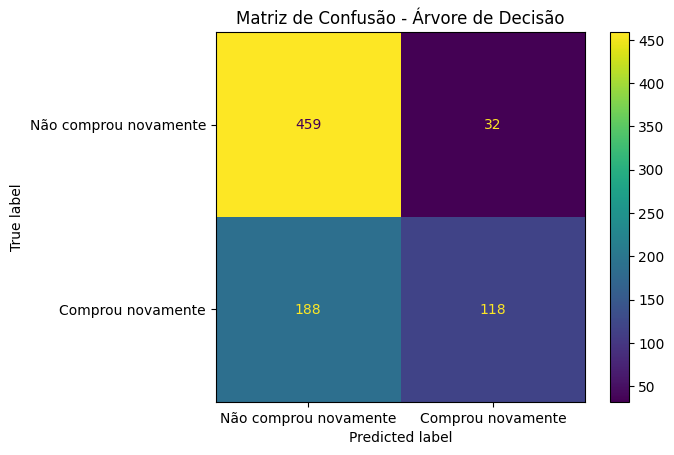

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Gerando a matriz de confusão
matriz = confusion_matrix(y_test, y_pred)

print("Matriz de confusão:")
print(matriz)

# Exibindo a matriz de forma visual
disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=["Não comprou novamente", "Comprou novamente"]
)

disp.plot()
plt.title("Matriz de Confusão - Árvore de Decisão")
plt.show()

### Interpretação da matriz de confusão

A matriz de confusão mostra que o modelo acertou 459 clientes que não compraram novamente e 118 clientes que compraram novamente.

Foram identificados 32 falsos positivos, ou seja, clientes que o modelo previu que comprariam novamente, mas que não realizaram uma nova compra.

Também ocorreram 188 falsos negativos, que são clientes que realmente compraram novamente, mas foram classificados pelo modelo como clientes que não comprariam.

No contexto do projeto, o falso positivo pode representar o envio de uma ação de marketing para um cliente que não teria comprado novamente. Já o falso negativo representa a perda de uma oportunidade de abordar um cliente que realmente voltou a comprar.

A quantidade de falsos negativos é maior que a quantidade de falsos positivos. Isso ajuda a explicar o recall relativamente baixo da classe "Comprou novamente", de 38,6%.

### Métrica principal escolhida

A métrica principal escolhida para este projeto é o recall da classe "Comprou novamente".

Essa escolha está relacionada ao objetivo de identificar clientes que realmente têm potencial de realizar uma nova compra. Um falso negativo representa um cliente que realmente comprou novamente, mas que não foi identificado pelo modelo. Nesse caso, existe o risco de perder uma oportunidade de direcionar uma ação de relacionamento ou marketing para esse cliente.

Por outro lado, um falso positivo representa um cliente que foi identificado como possível comprador, mas que não realizou uma nova compra. Esse erro pode gerar uma ação de marketing desnecessária.

Neste projeto, considero mais importante reduzir a quantidade de clientes que realmente recomprariam e que não são identificados pelo modelo. Por isso, o recall é a métrica principal, mesmo que isso implique aceitar uma quantidade maior de falsos positivos.

In [40]:
# Avaliando o desempenho do modelo nos dados de treino e de teste
acuracia_treino = modelo.score(X_train, y_train)
acuracia_teste = modelo.score(X_test, y_test)

diferenca = acuracia_treino - acuracia_teste

print("Acurácia no treino:", acuracia_treino)
print("Acurácia no teste:", acuracia_teste)
print("Diferença entre treino e teste:", diferenca)

Acurácia no treino: 0.7214554579673776
Acurácia no teste: 0.7239648682559598
Diferença entre treino e teste: -0.0025094102885822034


### Teste de overfitting

A acurácia do modelo foi de 72,15% nos dados de treino e de 72,40% nos dados de teste. A diferença entre os dois resultados foi de aproximadamente -0,25 ponto percentual.

Como os desempenhos são muito próximos, não foi observado um sinal de overfitting. O modelo não apresentou uma acurácia muito maior no conjunto de treino em relação ao conjunto de teste.

O fato de a acurácia no teste ter ficado ligeiramente acima da acurácia no treino não indica, por si só, um problema de generalização. A diferença é muito pequena e pode ocorrer devido à divisão dos dados.

In [41]:
# Verificando se existem clientes duplicados no conjunto de dados
duplicatas = X.index.duplicated().sum()

print("Quantidade de clientes duplicados:", duplicatas)
print("Quantidade total de clientes:", len(X))

Quantidade de clientes duplicados: 0
Quantidade total de clientes: 3985


### Verificação de possível vazamento de dados

Foi verificada a possibilidade de vazamento de dados durante a preparação e avaliação do modelo.

As duplicatas exatas foram removidas anteriormente, durante a etapa de limpeza da base, antes da divisão dos dados para a modelagem. Na verificação realizada sobre os clientes utilizados no modelo, não foram encontradas duplicações, totalizando 0 clientes duplicados entre os 3.985 registros.

Também foi respeitada a ordem cronológica do problema. As características dos clientes foram calculadas somente com compras realizadas antes da data de corte de novembro de 2011, enquanto o alvo foi construído utilizando as compras realizadas depois dessa data. Dessa forma, informações do futuro não foram utilizadas para criar as características do modelo.

Depois da separação temporal entre passado e futuro, cada linha passou a representar um cliente com características calculadas no passado e um resultado futuro já definido. Por isso, foi utilizada uma divisão aleatória estratificada de 80% para treinamento e 20% para teste entre os clientes, mantendo a proporção das classes.

Além disso, a transformação da variável `Pais` foi realizada somente depois da divisão entre treino e teste, evitando utilizar informações do conjunto de teste para definir a transformação utilizada no treinamento.

Por fim, o `CustomerID` não foi utilizado como característica do modelo e nenhuma das variáveis utilizadas entrega diretamente a resposta futura.

Com essas verificações, não foi identificado um problema evidente de vazamento de dados que explique o resultado obtido.

## Conclusão da avaliação do modelo

A Árvore de Decisão apresentou acurácia de 72,40%, acima do baseline de 61,61%, indicando que o modelo conseguiu aprender padrões úteis para identificar clientes que podem realizar uma nova compra.

O modelo apresenta melhor desempenho em precisão do que em recall. A precisão foi de 78,67%, enquanto o recall da classe "Comprou novamente" foi de 38,56%. Isso significa que, quando o modelo prevê que um cliente fará uma nova compra, ele apresenta uma boa taxa de acerto, mas ainda deixa passar uma parte significativa dos clientes que realmente voltariam a comprar.

No contexto do projeto, o principal erro é o falso negativo, pois representa um cliente que voltaria a comprar, mas que não foi identificado pelo modelo. Isso pode representar uma oportunidade perdida de relacionamento ou de uma ação de marketing. Por esse motivo, o recall da classe "Comprou novamente" foi definido como a principal métrica de avaliação.

A comparação entre treino e teste não indicou um problema grave de overfitting, e as verificações realizadas também não identificaram um problema evidente de vazamento de dados.

Como limitação atual, o modelo ainda apresenta recall baixo e 188 falsos negativos. Por isso, uma das próximas etapas do projeto será investigar formas de aumentar a capacidade de identificar clientes com potencial de recompra, mantendo uma avaliação adequada dos demais erros.